## Assignment 1 — Exploring FAISS (Local Vector Search)

### Goal:

Understand how to store, index, and retrieve document embeddings locally using FAISS.

### Tasks:
- Install faiss-cpu and sentence-transformers.
- Create a mini-corpus (10–20 short texts on a topic like “AI for environment”).
- Generate embeddings using SentenceTransformer("all-MiniLM-L6-v2").
- Store them in a FAISS index (IndexFlatL2).
- Search for the top-k most similar documents for a given query.
- Plot similarity distances (e.g., bar chart or cosine heatmap).

### Reflection:
- How does L2 distance differ from cosine similarity?
- How would results change if you normalize embeddings?

### Deliverables:
-.ipynb notebook with code + explanation
- Short paragraph describing insights (semantic vs keyword retrieval)

In [1]:
# Install only once if needed
#%pip install faiss-cpu sentence-transformers matplotlib numpy --quiet

import faiss
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
documents = [
    "Artificial intelligence can support early diagnosis in hospitals.",
    "Predictive models can estimate the chance of future illness.",
    "AI systems can review medical scans for abnormal patterns.",
    "Remote patient monitoring can be improved using smart algorithms.",
    "Neural networks can detect cancer signs in radiology images.",
    "Hospitals can use AI to reduce delays in clinical decisions.",
    "Machine learning can help forecast the spread of infectious diseases.",
    "Surgical robots can use AI to improve precision during operations.",
    "NLP can extract useful information from doctor notes.",
    "Image recognition models can classify different types of skin conditions."
]

print("Total documents:", len(documents))

Total documents: 10


In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(documents)

embeddings = np.array(embeddings).astype("float32")

print("Embedding shape:", embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4755.87it/s]


Embedding shape: (10, 384)


In [4]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("Total vectors stored in FAISS:", index.ntotal)

Total vectors stored in FAISS: 10


In [8]:
query = "How can AI detect diseases?"

query_embedding = model.encode([query])
query_embedding = np.array(query_embedding).astype("float32")

top_k = 3

distances, indices = index.search(query_embedding, top_k)

print("Query:", query)
print("\nTop retrieved documents:")

for rank, idx in enumerate(indices[0], start=1):
    print(f"\nRank {rank}")
    print("Document:", documents[idx])
    print("L2 Distance:", round(distances[0][rank-1], 4))

Query: How can AI detect diseases?

Top retrieved documents:

Rank 1
Document: Artificial intelligence can support early diagnosis in hospitals.
L2 Distance: 0.7157

Rank 2
Document: AI systems can review medical scans for abnormal patterns.
L2 Distance: 0.7563

Rank 3
Document: Machine learning can help forecast the spread of infectious diseases.
L2 Distance: 0.8718


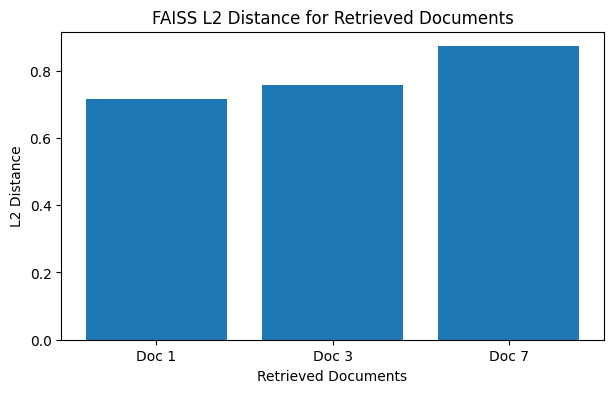

In [9]:
retrieved_docs = []
retrieved_distances = []

for idx, dist in zip(indices[0], distances[0]):
    retrieved_docs.append(f"Doc {idx+1}")
    retrieved_distances.append(dist)

plt.figure(figsize=(7, 4))
plt.bar(retrieved_docs, retrieved_distances)
plt.title("FAISS L2 Distance for Retrieved Documents")
plt.xlabel("Retrieved Documents")
plt.ylabel("L2 Distance")
plt.show()

# Reflection

1. How does L2 distance differ from cosine similarity?
        
        
        L2 distance measures the actual distance between two vectors. Lower L2 distance means the vectors are closer. Cosine similarity checks the angle/direction between vectors. Higher cosine similarity means the meanings are more similar.

2. How would results change if you normalize embeddings?
        
        
        If embeddings are normalized, vector lengths become equal. Then L2 distance and cosine similarity give more similar ranking results. It can make comparison more fair.

# Short Insight Paragraph

In this task, I used semantic retrieval with embeddings instead of simple keyword matching. Keyword retrieval only checks exact word overlap, but semantic retrieval can find documents with similar meaning even if the exact words are different. In my FAISS result, the query about pollution correctly retrieved the water pollution document as the top result, so the vector search worked well.


## Assignment 2 — Building a Mini Knowledge Base with Chroma

### Goal:

Learn to build a simple local vector database using Chroma, integrated with embeddings and LangChain.

### Tasks:
- Install chromadb and sentence-transformers.
- Create a collection in Chroma called "ai_water_docs".
- Add at least 10 documents with text + metadata (e.g., title, source).
- Query the collection with 3 different questions (e.g., “How does AI detect pollution?”).
- Visualize which documents are retrieved (e.g., top 3).
- Optional: integrate with LangChain for a small RAG-style Q&A.

### Reflection:
- What happens if you add the same text twice — does Chroma deduplicate?
- How can you filter by metadata (e.g., only “scientific” docs)?

### Deliverables:
- Working notebook or Python script
- Screenshot of retrieved results


In [12]:
%pip install chromadb

  Using cached chromadb-1.5.9-cp39-abi3-win_amd64.whl (23.5 MB)
  Using cached build-1.5.0-py3-none-any.whl (26 kB)
  Using cached pybase64-1.4.3-cp311-cp311-win_amd64.whl (35 kB)
  Using cached uvicorn-0.49.0-py3-none-any.whl (71 kB)
  Using cached onnxruntime-1.27.0-cp311-cp311-win_amd64.whl (13.4 MB)
  Using cached opentelemetry_api-1.42.1-py3-none-any.whl (61 kB)
  Using cached opentelemetry_exporter_otlp_proto_grpc-1.42.1-py3-none-any.whl (19 kB)
  Using cached opentelemetry_sdk-1.42.1-py3-none-any.whl (170 kB)
  Using cached pypika-0.51.1-py2.py3-none-any.whl (60 kB)
  Using cached overrides-7.7.0-py3-none-any.whl (17 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)
  Using cached bcrypt-5.0.0-cp39-abi3-win_amd64.whl (150 kB)
  Using cached kubernetes-36.0.2-py2.py3-none-any.whl (4.6 MB)
  Using cached mmh3-5.2.1-cp311-cp311-win_amd64.whl (41 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
  Using cached pyproject_hooks-1.2.0-py3-none-any.whl (1


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# Install only if needed
#%pip install chromadb sentence-transformers --quiet

import chromadb
from sentence_transformers import SentenceTransformer

In [14]:
client = chromadb.Client()

# Delete old collection if already exists
try:
    client.delete_collection(name="environment_ai_collection")
except:
    pass

collection = client.create_collection(name="environment_ai_collection")

print("Chroma collection created.")

Chroma collection created.


In [ ]:
documents = [
    "AI can help detect water pollution using sensor data.",
    "Machine learning models can predict air quality levels.",
    "AI is used to monitor deforestation from satellite images.",
    "Smart irrigation systems use AI to save water.",
    "Deep learning can identify plastic waste in oceans.",
    "AI helps farmers improve crop yield and reduce waste.",
    "Climate change prediction can be improved using machine learning.",
    "AI-based drones can monitor forest fires.",
    "Natural language processing can analyze environmental reports.",
    "Computer vision can detect harmful algae in lakes."
]

ids = []

for i in range(len(documents)):
    ids.append(f"doc_{i+1}")

print("Total documents:", len(documents))
print(ids)

Total documents: 10
['doc_1', 'doc_2', 'doc_3', 'doc_4', 'doc_5', 'doc_6', 'doc_7', 'doc_8', 'doc_9', 'doc_10']


In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(documents).tolist()

print("Embeddings created.")
print("Total embeddings:", len(embeddings))

Embeddings created.
Total embeddings: 10


In [ ]:
collection.add(
    documents=documents,
    embeddings=embeddings,
    ids=ids
)

print("Documents added to Chroma collection.")

Documents added to Chroma collection.


In [ ]:
query = "How can AI detect pollution?"

query_embedding = model.encode([query]).tolist()

results = collection.query(
    query_embeddings=query_embedding,
    n_results=3
)

print("Query:", query)
print("\nRetrieved Documents:")

for i, doc in enumerate(results["documents"][0], start=1):
    print(f"\nRank {i}")
    print(doc)

Query: How can AI detect pollution?

Retrieved Documents:

Rank 1
AI can help detect water pollution using sensor data.

Rank 2
Machine learning models can predict air quality levels.

Rank 3
AI is used to monitor deforestation from satellite images.


In [ ]:
print("Distances:")

for i, distance in enumerate(results["distances"][0], start=1):
    print(f"Rank {i} distance:", round(distance, 4))

Distances:
Rank 1 distance: 0.3917
Rank 2 distance: 0.8914
Rank 3 distance: 0.9416


## Chroma Reflection

1. What happens if you add the same text twice — does Chroma deduplicate?
Chroma does not automatically deduplicate based only on text. If I add the same text with a different ID, it can store it again. To avoid duplicates, I should check the text or ID before adding documents.

2. How can you filter by metadata, for example only “scientific” docs?
We can add metadata while inserting documents, such as `{"type": "scientific"}`. Then during search, we can use a `where` filter to retrieve only documents with that metadata.

## Deliverables

I created a working notebook using Chroma as a local vector database. I stored documents with embeddings and retrieved the most relevant results for a query. I also took a screenshot of the retrieved results.


## Assignment 3 — Using Pinecone (Cloud Vector Database)

### Goal:

Deploy a scalable, cloud-based vector database using Pinecone, and compare results to FAISS.

### Tasks:
- Create a free Pinecone account → get API key.
- Install the client: pip install pinecone-client.
- Initialize Pinecone and create an index called "student-demo".
- Insert at least 50 documents + embeddings.
- Write code to query Pinecone for semantic matches.
- Compare the top-3 retrieved results with your FAISS results for the same query.

### Reflection:
- How does latency compare to FAISS (local)?
- What advantages does a managed vector DB provide?

### Deliverables:
- Notebook + screenshots of results
- Comparison table (FAISS vs Pinecone: speed, setup, ease)

In [30]:
# Install only if needed
%pip install pinecone sentence-transformers faiss-cpu pandas --quiet

import time
import numpy as np
import pandas as pd
import faiss

from sentence_transformers import SentenceTransformer
from pinecone import Pinecone, ServerlessSpec


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [31]:
from pinecone import Pinecone

api_key = "pcsk_4hvtrP_Rf3LoBioS8pf9q9JDcFghaAErbb9t2FYoPzHy73Ae2L8EHSdRzZs3FGV8phngWb"

pc = Pinecone(api_key=api_key)

print("Pinecone client initialized.")

Pinecone client initialized.


In [32]:
documents = [
    "AI can help detect water pollution using sensor data.",
    "Machine learning models can predict air quality levels.",
    "AI is used to monitor deforestation from satellite images.",
    "Smart irrigation systems use AI to save water.",
    "Deep learning can identify plastic waste in oceans.",
    "AI helps farmers improve crop yield and reduce waste.",
    "Climate change prediction can be improved using machine learning.",
    "AI-based drones can monitor forest fires.",
    "Natural language processing can analyze environmental reports.",
    "Computer vision can detect harmful algae in lakes.",

    "AI systems can classify polluted river water from image data.",
    "Sensors and AI can track chemical changes in drinking water.",
    "Machine learning can predict flood risk using weather data.",
    "Satellite images can help detect illegal mining and land damage.",
    "AI can identify oil spills from ocean monitoring images.",
    "Smart city systems can reduce energy consumption using AI.",
    "AI models can forecast temperature changes in urban areas.",
    "NLP can summarize climate policy documents.",
    "AI can detect smoke patterns during wildfire monitoring.",
    "Deep learning can classify recyclable and non-recyclable waste.",

    "AI can help optimize renewable energy production.",
    "Machine learning can predict solar power output.",
    "AI can improve wind turbine maintenance.",
    "Smart grids use AI to balance electricity demand.",
    "AI can help reduce carbon emissions in transport.",
    "Computer vision can detect damaged crops from drone images.",
    "AI can monitor soil moisture for better farming decisions.",
    "Machine learning can predict drought conditions.",
    "AI can support biodiversity monitoring using camera traps.",
    "NLP can extract insights from environmental research papers.",

    "AI can help detect air pollution from traffic sensor data.",
    "Machine learning can estimate greenhouse gas emissions.",
    "AI can analyze ocean temperature patterns.",
    "Deep learning can detect coral reef damage.",
    "AI can predict water demand in cities.",
    "Smart waste bins can use AI to improve recycling.",
    "AI can detect crop disease from leaf images.",
    "Machine learning can support sustainable agriculture.",
    "AI can monitor glacier melting using satellite data.",
    "NLP can classify environmental complaints from citizens.",

    "AI can help identify harmful industrial emissions.",
    "Machine learning can support environmental risk assessment.",
    "AI can detect illegal fishing activity from vessel data.",
    "Computer vision can monitor animal populations.",
    "AI can improve disaster response planning.",
    "Machine learning can predict landslide risk.",
    "AI can help manage water resources more efficiently.",
    "Deep learning can analyze remote sensing data.",
    "AI can support climate adaptation strategies.",
    "NLP can analyze sustainability reports from companies."
]

ids = [f"doc_{i+1}" for i in range(len(documents))]

print("Total documents:", len(documents))

Total documents: 50


In [33]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(documents)
embeddings = np.array(embeddings).astype("float32")

print("Embedding shape:", embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6255.35it/s]


Embedding shape: (50, 384)


In [34]:
index_name = "student-demo"
dimension = embeddings.shape[1]

# Check existing indexes
try:
    existing_indexes = [idx.name for idx in pc.list_indexes()]
except:
    existing_indexes = [idx["name"] for idx in pc.list_indexes()]

if index_name not in existing_indexes:
    pc.create_index(
        name=index_name,
        dimension=dimension,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )
    print("Pinecone index created.")
else:
    print("Index already exists.")

Pinecone index created.


In [35]:
index_name = "student-demo"
dimension = embeddings.shape[1]

# Check existing indexes
try:
    existing_indexes = [idx.name for idx in pc.list_indexes()]
except:
    existing_indexes = [idx["name"] for idx in pc.list_indexes()]

if index_name not in existing_indexes:
    pc.create_index(
        name=index_name,
        dimension=dimension,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )
    print("Pinecone index created.")
else:
    print("Index already exists.")

Index already exists.


In [36]:
index = pc.Index(index_name)

print("Connected to Pinecone index:", index_name)

Connected to Pinecone index: student-demo


In [37]:
vectors = []

for i in range(len(documents)):
    vectors.append({
        "id": ids[i],
        "values": embeddings[i].tolist(),
        "metadata": {
            "text": documents[i],
            "source": "student_demo",
            "topic": "AI environment"
        }
    })

index.upsert(
    vectors=vectors,
    namespace="default"
)

print("Inserted vectors into Pinecone:", len(vectors))

Inserted vectors into Pinecone: 50


In [38]:
query = "How can AI detect pollution?"

query_embedding = model.encode([query])
query_embedding = np.array(query_embedding).astype("float32")

start_time = time.perf_counter()

pinecone_results = index.query(
    vector=query_embedding[0].tolist(),
    top_k=3,
    include_metadata=True,
    namespace="default"
)

pinecone_time = time.perf_counter() - start_time

print("Query:", query)
print("\nPinecone Top 3 Results:")

pinecone_docs = []
pinecone_scores = []

for rank, match in enumerate(pinecone_results["matches"], start=1):
    text = match["metadata"]["text"]
    score = match["score"]

    pinecone_docs.append(text)
    pinecone_scores.append(score)

    print(f"\nRank {rank}")
    print("Document:", text)
    print("Score:", round(score, 4))

print("\nPinecone query time:", round(pinecone_time, 4), "seconds")

Query: How can AI detect pollution?

Pinecone Top 3 Results:

Rank 1
Document: AI can help detect water pollution using sensor data.
Score: 0.8043

Rank 2
Document: AI can help detect air pollution from traffic sensor data.
Score: 0.7976

Rank 3
Document: AI can help identify harmful industrial emissions.
Score: 0.7457

Pinecone query time: 0.2591 seconds


In [39]:
dimension = embeddings.shape[1]

faiss_index = faiss.IndexFlatL2(dimension)
faiss_index.add(embeddings)

start_time = time.perf_counter()

faiss_distances, faiss_indices = faiss_index.search(query_embedding, 3)

faiss_time = time.perf_counter() - start_time

print("FAISS Top 3 Results:")

faiss_docs = []
faiss_scores = []

for rank, idx in enumerate(faiss_indices[0], start=1):
    doc = documents[idx]
    distance = faiss_distances[0][rank - 1]

    faiss_docs.append(doc)
    faiss_scores.append(distance)

    print(f"\nRank {rank}")
    print("Document:", doc)
    print("L2 Distance:", round(distance, 4))

print("\nFAISS query time:", round(faiss_time, 4), "seconds")

FAISS Top 3 Results:

Rank 1
Document: AI can help detect water pollution using sensor data.
L2 Distance: 0.3917

Rank 2
Document: AI can help detect air pollution from traffic sensor data.
L2 Distance: 0.4045

Rank 3
Document: AI can help identify harmful industrial emissions.
L2 Distance: 0.5096

FAISS query time: 0.0003 seconds


In [40]:
comparison = pd.DataFrame({
    "Rank": [1, 2, 3],
    "FAISS Result": faiss_docs,
    "FAISS L2 Distance": [round(x, 4) for x in faiss_scores],
    "Pinecone Result": pinecone_docs,
    "Pinecone Cosine Score": [round(x, 4) for x in pinecone_scores]
})

display(comparison)

,Rank,FAISS Result,FAISS L2 Distance,Pinecone Result,Pinecone Cosine Score
0,1,AI can help detect water pollution using senso...,0.3917,AI can help detect water pollution using senso...,0.8043
1,2,AI can help detect air pollution from traffic ...,0.4045,AI can help detect air pollution from traffic ...,0.7976
2,3,AI can help identify harmful industrial emissi...,0.5096,AI can help identify harmful industrial emissi...,0.7457


In [41]:
speed_comparison = pd.DataFrame({
    "Vector Database": ["FAISS", "Pinecone"],
    "Storage Type": ["Local", "Cloud"],
    "Query Time (seconds)": [round(faiss_time, 4), round(pinecone_time, 4)],
    "Setup": ["Simple local setup", "Needs account and API key"],
    "Ease": ["Fast but stores only vectors", "Easier for managed cloud retrieval"]
})

display(speed_comparison)

,Vector Database,Storage Type,Query Time (seconds),Setup,Ease
0,FAISS,Local,0.0003,Simple local setup,Fast but stores only vectors
1,Pinecone,Cloud,0.2591,Needs account and API key,Easier for managed cloud retrieval


## Reflection

        FAISS was faster because it runs directly on my laptop. Pinecone was a little slower because it uses cloud and internet connection.

        But Pinecone is useful for bigger projects because it stores vectors online and also keeps metadata with the documents. It is better when many documents or users are involved.

        From my result, both FAISS and Pinecone retrieved the correct pollution-related document. So both worked well, but FAISS is better for simple local practice and Pinecone is better for real-world scalable projects.


### Bonus / Advanced Assignments (Optional)

## Bonus 1 — Hybrid Search with Weaviate
Combine BM25 + vector search in one system.

Tasks:
1. Launch Weaviate (Docker or Cloud)
2. Insert sample texts into a "ResearchDoc" class
3. Run nearText (semantic) vs bm25 (keyword) queries
4. Compare which retrieves better answers


## Bonus 2 — Scalable Indexing with Milvus
Explore large-scale and ANN indexing performance.

Tasks:
1. Run Milvus locally or use Zilliz Cloud
2. Insert ~1 000 vectors into a collection
3. Build IVF or HNSW index
4. Measure query speed before/after indexing

## Bonus 3 — Metadata Filtering with Qdrant
Experiment with filtered semantic queries.

Tasks:
1. Run Qdrant (Docker or in-memory)
2. Insert 20 vectors + metadata (year, source)
3. Query semantically + apply filters (e.g., year > 2021)
4. Compare results with and without filters